In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_style("whitegrid")

In [4]:
df=pd.read_csv("../data/student-mat.csv",sep=";")

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.shape

(395, 33)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [9]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

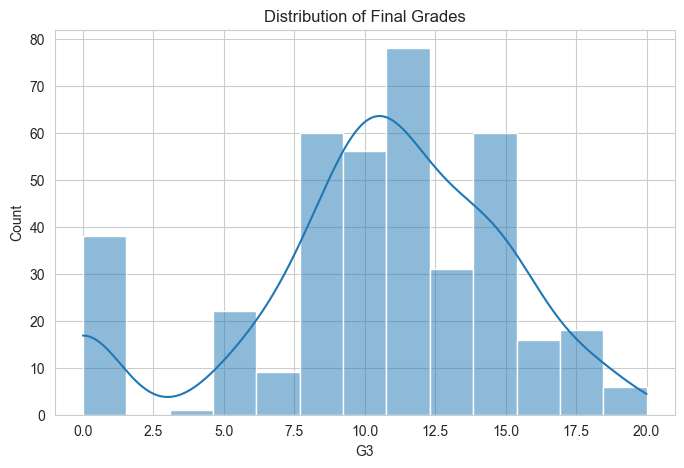

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["G3"], kde=True)
plt.title("Distribution of Final Grades")
plt.show()

In [11]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [13]:
df["sex"].value_counts()

sex
F    208
M    187
Name: count, dtype: int64

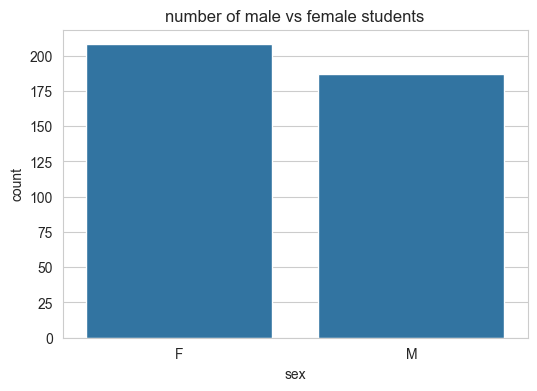

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex",data=df)
plt.title("number of male vs female students")
plt.show()


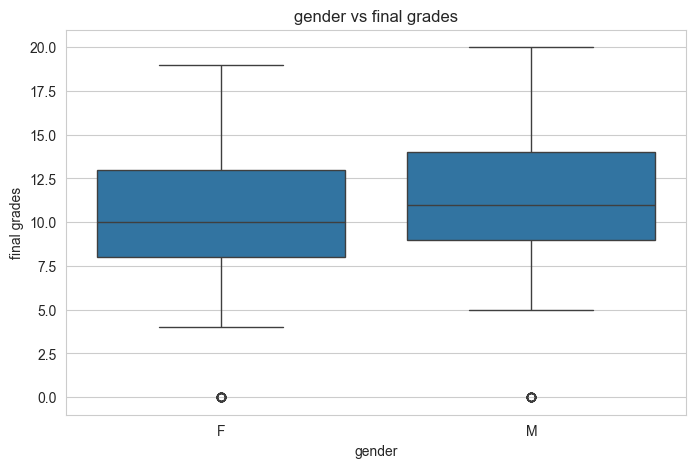

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="sex",y="G3",data=df)
plt.title("gender vs final grades")
plt.xlabel("gender")
plt.ylabel("final grades")
plt.show()

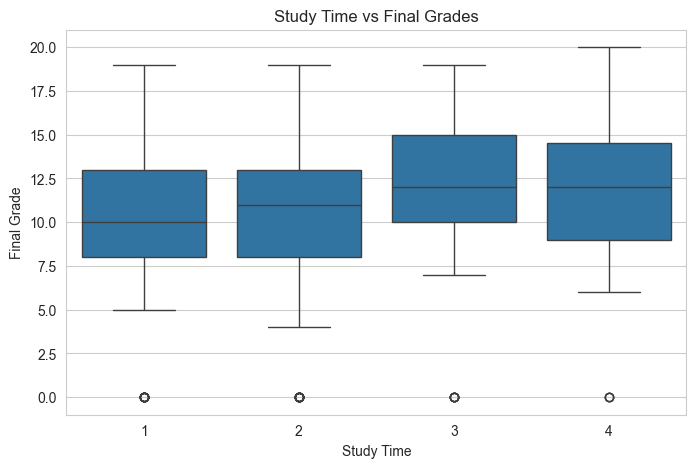

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="studytime", y="G3", data=df)
plt.title("Study Time vs Final Grades")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

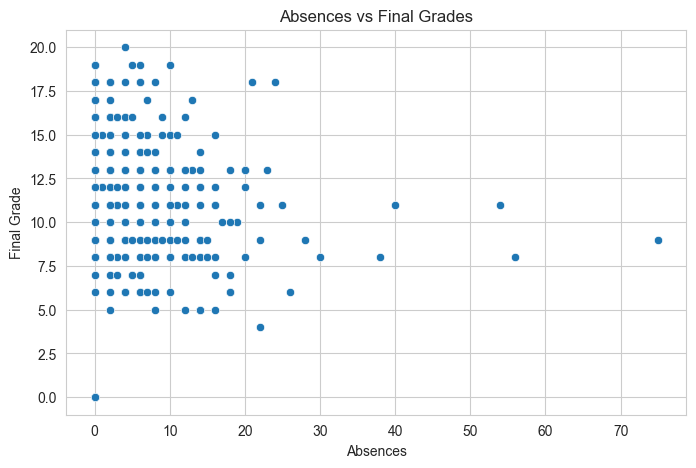

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="absences", y="G3", data=df)
plt.title("Absences vs Final Grades")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.show()

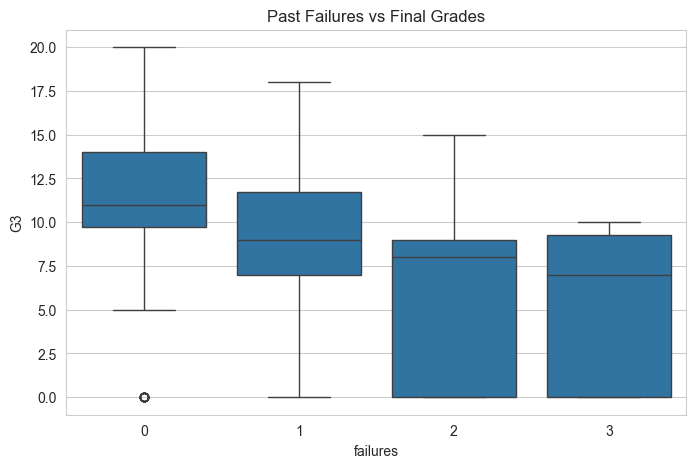

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="failures", y="G3", data=df)
plt.title("Past Failures vs Final Grades")
plt.show()

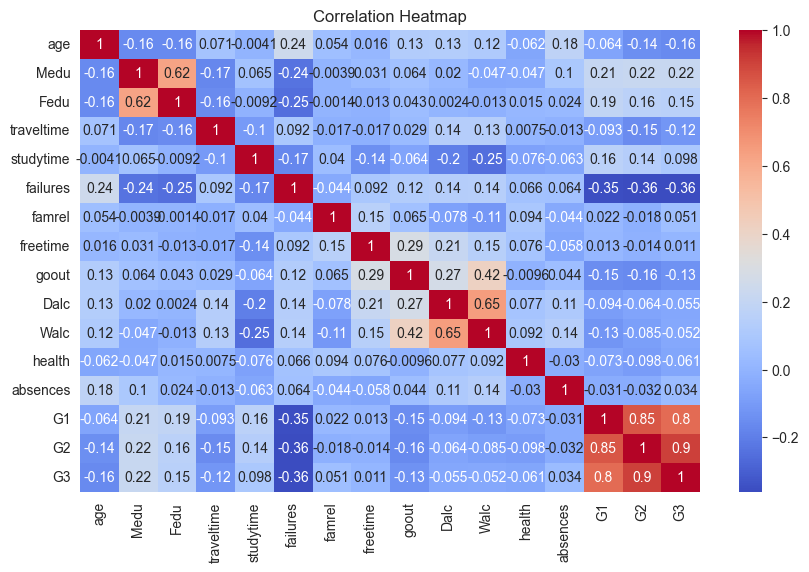

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

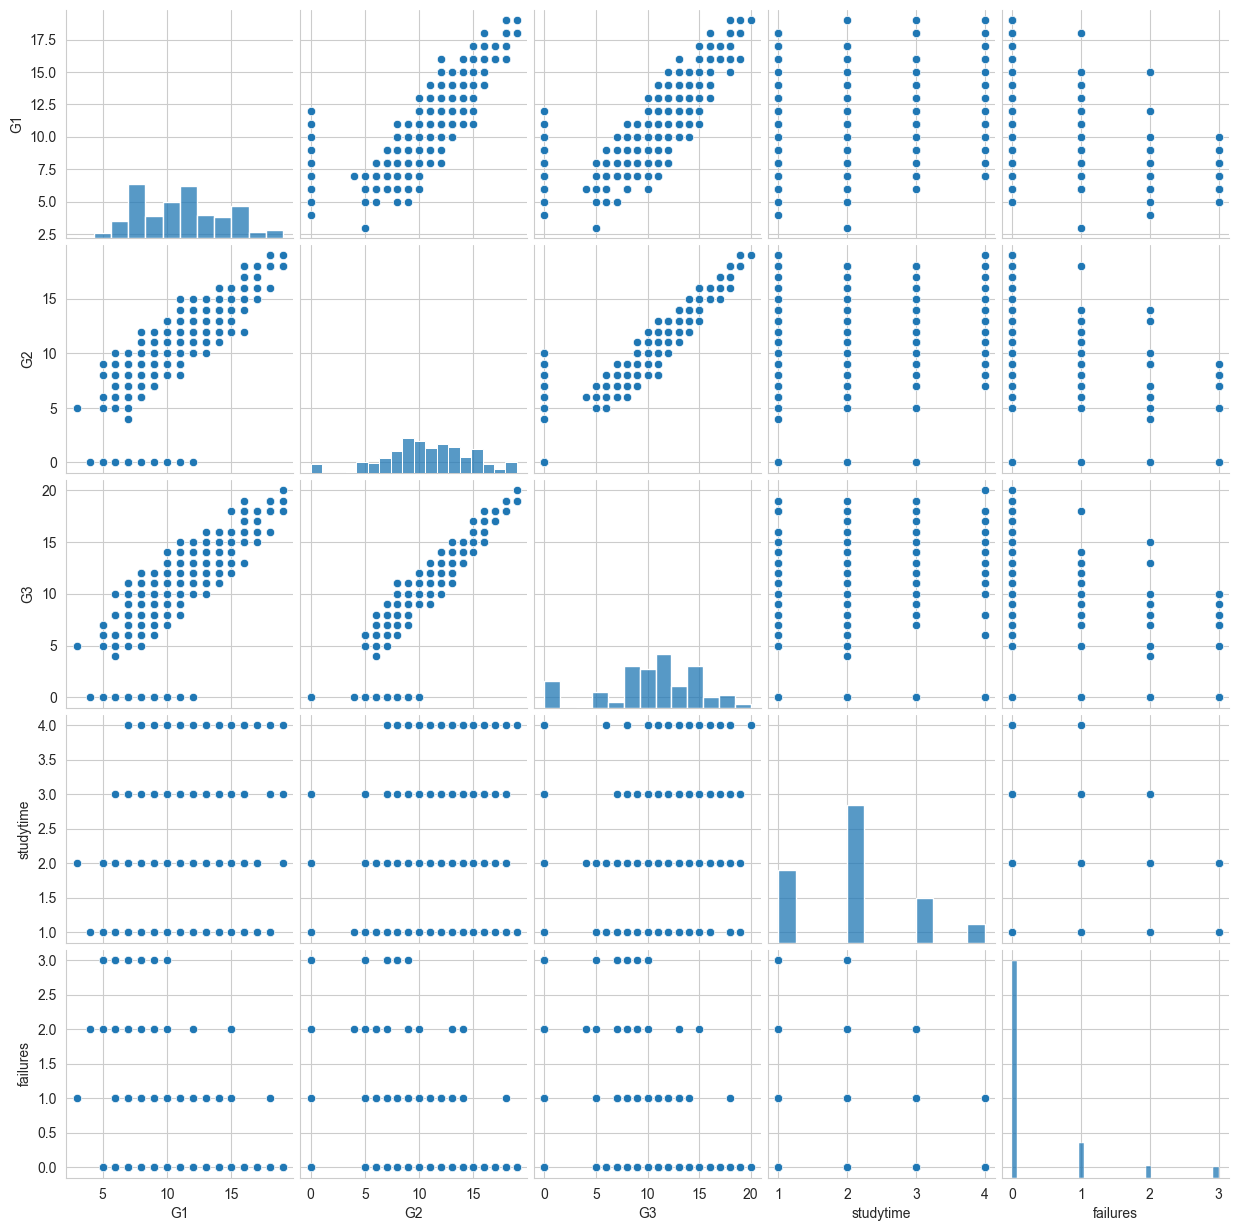

In [21]:
sns.pairplot(df[["G1","G2","G3","studytime","failures"]])

Key Insights from EDA

1. Final grade (G3) is strongly correlated with earlier grades (G1 and G2).
2. Students with more past failures tend to have lower final grades.
3. Higher study time generally leads to better performance.
4. Students with many absences often have lower grades.
5. Gender does not show a strong difference in final grade distribution.
   

In [22]:
df["average_grade"] = (df["G1"] + df["G2"] + df["G3"]) / 3

In [23]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,average_grade
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,5.666667
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,5.333333
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,8.333333
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,14.666667
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,8.666667


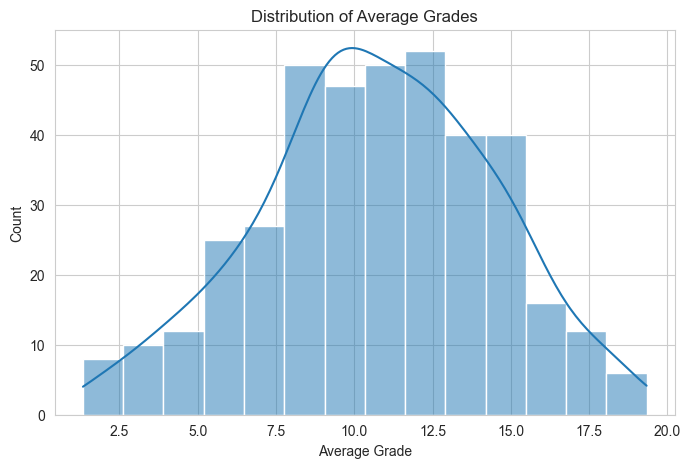

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["average_grade"], kde=True)
plt.title("Distribution of Average Grades")
plt.xlabel("Average Grade")
plt.ylabel("Count")
plt.show()

In [25]:
df[["G1","G2","G3"]].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


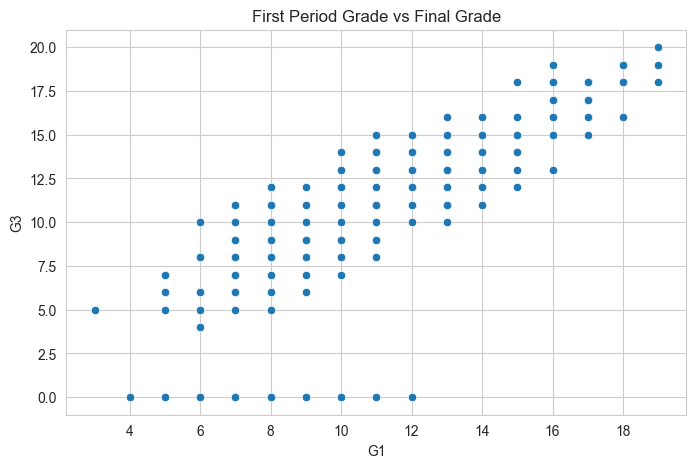

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="G1", y="G3", data=df)
plt.title("First Period Grade vs Final Grade")
plt.show()

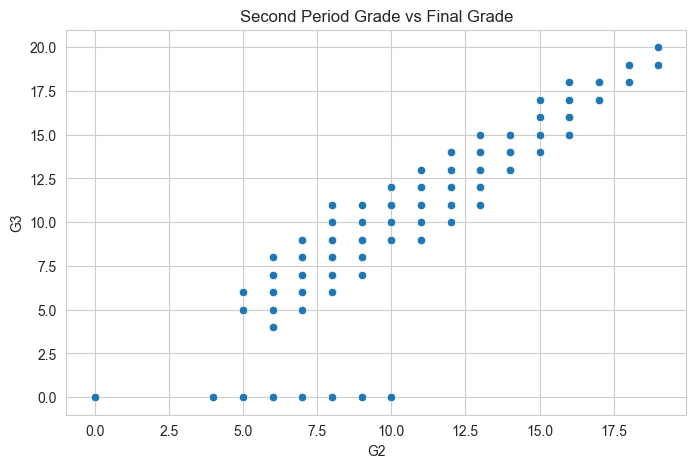

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="G2", y="G3", data=df)
plt.title("Second Period Grade vs Final Grade")
plt.show()

In [28]:
X = df[["G1","G2","studytime","failures","absences"]]
y = df["G3"]

In [29]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 8.2 MB/s eta 0:00:01
   ----------------- ---------------------- 3.4/8.0 MB 8.5 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 9.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 8.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.5 MB 9.0 MB/s eta 0:00:04
   ---- ----------------------------------- 3.7/36.5 MB 9.2 MB/s eta 0:00:04
   ------ --------------------------------- 5.5/36.5 MB 8.5 MB/s eta 0:00:04
   ------- -------------------------------- 6.8/36.5 MB 8.3 MB/s eta 0:00:04
   --------- ------------------------------ 8.4/36.5 MB 7.8 MB/s eta 0:00:04
   ---------- ----------------------------- 10.0/36.5 MB 7.9 MB/s eta 0:00:04
   ----------- ---


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
predictions = model.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.339415908267092


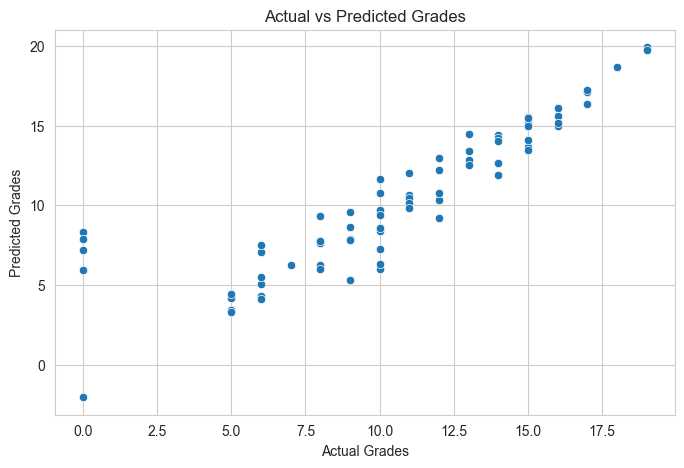

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")
plt.show()

Project Conclusion

1. Previous grades (G1 and G2) are the strongest predictors of final grade (G3).
2. Study time has a positive influence on student performance.
3. Students with more past failures generally perform worse.
4. Higher absenteeism is associated with lower grades.
5. A linear regression model can reasonably predict final grades using academic and behavioral features.